# Stage 08: Exploratory Data Analysis

**Project:** SPY Next-Day High-Volatility Risk Alert  
**Date:** 2026-08-24

This notebook performs comprehensive EDA on the real SPY OHLCV snapshot stored in Stage 05. It covers numeric, categorical, and datetime profiling; five visual summaries; daily-versus-monthly analysis; and implications for leakage-safe Stage 09 features and chronological modeling.

In [1]:
# Packages needed (run once in the course environment if missing):
# %pip install numpy scipy pandas pyarrow matplotlib seaborn

## 1. Reproducible setup and data lineage

The notebook locates `homework/homework08` independent of launch directory. On the first run it creates a local raw Parquet snapshot from Stage 05; on later runs it validates that snapshot against Stage 05 when the prerequisite remains available. No synthetic fallback is used.

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display


def locate_homework_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if candidate.name == "homework08" and (candidate / "src").exists():
            return candidate
        nested = candidate / "homework" / "homework08"
        if (nested / "src").exists():
            return nested
    raise FileNotFoundError("Could not locate homework/homework08")


ROOT = locate_homework_root()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
REPORTS = ROOT / "reports"
for directory in [RAW, PROCESSED, REPORTS]:
    directory.mkdir(parents=True, exist_ok=True)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.eda import eda_summary

sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_columns", 100)
print("Homework root:", ROOT)

Homework root: /Users/cengchengyu/Documents/NYU/Boot Camp/CS HW/Project/homework/homework08


In [3]:
stage05_dir = ROOT.parent / "homework05" / "data" / "processed"
stage05_candidates = sorted(stage05_dir.glob("spy_ohlcv_*.parquet"))
raw_snapshot = RAW / "spy_ohlcv_stage05_snapshot.parquet"

if not raw_snapshot.exists():
    if not stage05_candidates:
        raise FileNotFoundError(
            "Neither the Stage 08 raw snapshot nor a Stage 05 SPY Parquet file exists"
        )
    source_path = stage05_candidates[-1]
    source_frame = pd.read_parquet(source_path, engine="pyarrow")
    source_frame.to_parquet(raw_snapshot, index=False, engine="pyarrow")
    print("Created local raw snapshot from:", source_path.relative_to(ROOT.parents[1]))
else:
    print("Using committed raw snapshot:", raw_snapshot.relative_to(ROOT))

df = pd.read_parquet(raw_snapshot, engine="pyarrow")
if stage05_candidates:
    stage05_frame = pd.read_parquet(stage05_candidates[-1], engine="pyarrow")
    pd.testing.assert_frame_equal(df, stage05_frame)
    print("Stage 08 snapshot matches latest Stage 05 Parquet.")

required_columns = ["date", "open", "high", "low", "close", "volume"]
if list(df.columns) != required_columns:
    raise ValueError(f"Unexpected SPY schema: {list(df.columns)}")
df = df.sort_values("date", kind="stable").reset_index(drop=True)
print("Raw shape:", df.shape)
display(df.head(3))

Using committed raw snapshot: data/raw/spy_ohlcv_stage05_snapshot.parquet
Stage 08 snapshot matches latest Stage 05 Parquet.
Raw shape: (2512, 6)


,date,open,high,low,close,volume
0,2016-08-23,219.25,219.60,218.90,218.97,53289030
1,2016-08-24,218.80,218.91,217.36,217.85,71553010
2,2016-08-25,217.40,218.19,217.22,217.70,69128600


## 2. First look: `.info()`, missingness, and date integrity

The raw market table should contain one complete row per observed trading session. Date gaps are compared with generic weekdays, but U.S. exchange holidays are expected and are not automatically classified as missing data.

In [4]:
df.info()
display(df.describe().T)
display(df.isna().sum().rename("missing_count").to_frame())

<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2512 non-null   datetime64[us]
 1   open    2512 non-null   float64       
 2   high    2512 non-null   float64       
 3   low     2512 non-null   float64       
 4   close   2512 non-null   float64       
 5   volume  2512 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 117.9 KB


,count,mean,min,25%,50%,75%,max,std
date,2512,2021-08-19 22:20:15.286624,2016-08-23 00:00:00,2019-02-21 18:00:00,2021-08-18 12:00:00,2024-02-17 00:00:00,2026-08-21 00:00:00,NaN
open,2512.0,408.650202,208.91,281.5575,393.235,497.8975,778.54,144.839673
high,2512.0,410.848525,209.89,283.4975,396.335,501.7875,779.37,145.452578
low,2512.0,406.24962,208.38,280.152875,390.54,494.6775,775.4301,144.135387
close,2512.0,408.716959,208.55,281.5975,393.785,498.805,777.88,144.865935
volume,2512.0,79365604.916003,9999999.0,56179930.0,71061160.0,91523567.5,392220700.0,38459525.019428


,missing_count
date,0
open,0
high,0
low,0
close,0
volume,0


In [5]:
expected_weekdays = pd.bdate_range(df["date"].min(), df["date"].max())
missing_generic_weekdays = expected_weekdays.difference(pd.DatetimeIndex(df["date"]))
calendar_gaps = df["date"].diff().dt.days
calendar_audit = pd.DataFrame(
    [
        {
            "date_min": df["date"].min().date().isoformat(),
            "date_max": df["date"].max().date().isoformat(),
            "sessions": len(df),
            "duplicate_dates": int(df["date"].duplicated().sum()),
            "monotonic_increasing": bool(df["date"].is_monotonic_increasing),
            "weekend_rows": int((df["date"].dt.dayofweek >= 5).sum()),
            "maximum_calendar_gap_days": int(calendar_gaps.max()),
            "generic_weekdays_without_rows": len(missing_generic_weekdays),
        }
    ]
)
display(calendar_audit)
print("First 10 generic weekday gaps (mostly market holidays):")
display(pd.Series(missing_generic_weekdays[:10], name="date").to_frame())

,date_min,date_max,sessions,duplicate_dates,monotonic_increasing,weekend_rows,maximum_calendar_gap_days,generic_weekdays_without_rows
0,2016-08-23,2026-08-21,2512,0,True,0,4,97


First 10 generic weekday gaps (mostly market holidays):


,date
0,2016-09-05
1,2016-11-24
2,2016-12-26
3,2017-01-02
4,2017-01-16
5,2017-02-20
6,2017-04-14
7,2017-05-29
8,2017-07-04
9,2017-09-04


## 3. EDA-only derived variables

Returns and ratios are more comparable through time than the nonstationary price level. `return_direction` and `weekday_name` provide meaningful categorical profiles. The 21-session rolling volatility is annualized and uses only the current and prior rows, but it is still an exploratory definition rather than a finalized Stage 09 feature.

In [6]:
eda_df = df.copy()
eda_df["daily_return"] = eda_df["close"].pct_change(fill_method=None)
eda_df["abs_return"] = eda_df["daily_return"].abs()
eda_df["intraday_range"] = (eda_df["high"] - eda_df["low"]) / eda_df["open"]
eda_df["close_to_open_return"] = eda_df["close"] / eda_df["open"] - 1
eda_df["log_volume"] = np.log1p(eda_df["volume"])
eda_df["rolling_vol_21"] = (
    eda_df["daily_return"].rolling(21).std(ddof=1) * np.sqrt(252)
)
direction_values = np.select(
    [eda_df["daily_return"].gt(0), eda_df["daily_return"].lt(0)],
    ["Up", "Down"],
    default="Flat",
)
direction_values = np.where(eda_df["daily_return"].isna(), "Missing", direction_values)
eda_df["return_direction"] = pd.Categorical(
    direction_values, categories=["Down", "Flat", "Up", "Missing"]
)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
eda_df["weekday_name"] = pd.Categorical(
    eda_df["date"].dt.day_name(), categories=weekday_order, ordered=True
)
display(eda_df.head(3))

,date,open,high,low,close,volume,daily_return,abs_return,intraday_range,close_to_open_return,log_volume,rolling_vol_21,return_direction,weekday_name
0,2016-08-23,219.25,219.60,218.90,218.97,53289030,NaN,NaN,0.003193,-0.001277,17.791241,NaN,Missing,Tuesday
1,2016-08-24,218.80,218.91,217.36,217.85,71553010,-0.005115,0.005115,0.007084,-0.004342,18.085949,NaN,Down,Wednesday
2,2016-08-25,217.40,218.19,217.22,217.70,69128600,-0.000689,0.000689,0.004462,0.001380,18.051479,NaN,Down,Thursday


## 4. Reusable `eda_summary(df)`

The imported helper separates numeric, categorical, and datetime roles. It also flags missingness, near-zero variance, and dominant categories that need attention before feature engineering.

In [7]:
summaries = eda_summary(eda_df)
print("Overview")
display(summaries["overview"])
print("Column profile")
display(summaries["column_profile"])
print("Numeric summary")
display(summaries["numeric_summary"])
print("Datetime summary")
display(summaries["datetime_summary"])
print("Attention before Stage 09")
display(summaries["attention"])

column_profile_path = PROCESSED / "eda_column_profile.csv"
numeric_summary_path = PROCESSED / "eda_numeric_summary.csv"
categorical_summary_path = PROCESSED / "eda_categorical_summary.csv"
summaries["column_profile"].to_csv(column_profile_path, index=False)
summaries["numeric_summary"].to_csv(numeric_summary_path, index=False)
summaries["categorical_summary"].to_csv(categorical_summary_path, index=False)

Overview


,rows,columns,missing_cells,duplicate_rows,memory_bytes
0,2512,14,23,0,246777


Column profile


,column,role,dtype,non_null,missing_count,missing_fraction,unique_count,dominant_fraction,near_zero_variance,dominant_category,attention
0,date,datetime,datetime64[us],2512,0,0.000000,2512,0.000398,False,False,none
1,open,numeric,float64,2512,0,0.000000,2432,0.001194,False,False,none
2,high,numeric,float64,2512,0,0.000000,2431,0.001194,False,False,none
3,low,numeric,float64,2512,0,0.000000,2438,0.000796,False,False,none
4,close,numeric,float64,2512,0,0.000000,2436,0.000796,False,False,none
5,volume,numeric,int64,2512,0,0.000000,2511,0.000796,False,False,none
6,daily_return,numeric,float64,2511,1,0.000398,2507,0.001990,False,False,has_missing
7,abs_return,numeric,float64,2511,1,0.000398,2507,0.001990,False,False,has_missing
8,intraday_range,numeric,float64,2512,0,0.000000,2512,0.000398,False,False,none
9,close_to_open_return,numeric,float64,2512,0,0.000000,2505,0.003185,False,False,none


Numeric summary


,column,count,mean,std,min,25%,50%,75%,max,missing_count,missing_fraction,skew,kurtosis,unique_count
0,open,2512.0,4.086502e+02,1.448397e+02,2.089100e+02,2.815575e+02,3.932350e+02,4.978975e+02,7.785400e+02,0,0.000000,0.674160,-0.516358,2432
1,high,2512.0,4.108485e+02,1.454526e+02,2.098900e+02,2.834975e+02,3.963350e+02,5.017875e+02,7.793700e+02,0,0.000000,0.668922,-0.522304,2431
2,low,2512.0,4.062496e+02,1.441354e+02,2.083800e+02,2.801529e+02,3.905400e+02,4.946775e+02,7.754301e+02,0,0.000000,0.678863,-0.510816,2438
3,close,2512.0,4.087170e+02,1.448659e+02,2.085500e+02,2.815975e+02,3.937850e+02,4.988050e+02,7.778800e+02,0,0.000000,0.673455,-0.518011,2436
4,volume,2512.0,7.936560e+07,3.845953e+07,9.999999e+06,5.617993e+07,7.106116e+07,9.152357e+07,3.922207e+08,0,0.000000,2.698828,12.193782,2511
5,daily_return,2511.0,5.633707e-04,1.136010e-02,-1.094237e-01,-3.704870e-03,6.956360e-04,5.983371e-03,1.050193e-01,1,0.000398,-0.310544,14.663325,2507
6,abs_return,2511.0,7.377006e-03,8.656070e-03,0.000000e+00,2.055842e-03,5.037710e-03,9.701154e-03,1.094237e-01,1,0.000398,4.091737,30.398392,2507
7,intraday_range,2512.0,1.137227e-02,8.961511e-03,1.229256e-03,5.939159e-03,8.852325e-03,1.369107e-02,1.126175e-01,0,0.000000,3.387083,20.206949,2512
8,close_to_open_return,2512.0,1.901500e-04,8.562506e-03,-5.661155e-02,-3.343507e-03,5.359381e-04,4.268177e-03,1.118272e-01,0,0.000000,0.552774,15.413815,2505
9,log_volume,2512.0,1.810223e+01,4.020196e-01,1.611810e+01,1.784407e+01,1.807905e+01,1.833211e+01,1.978734e+01,0,0.000000,0.493207,1.097586,2511


Datetime summary


,column,minimum,maximum,unique_count,duplicate_count,monotonic_increasing
0,date,2016-08-23,2026-08-21,2512,0,True


Attention before Stage 09


,column,role,missing_count,missing_fraction,dominant_fraction,attention
0,daily_return,numeric,1,0.000398,0.00199,has_missing
1,abs_return,numeric,1,0.000398,0.00199,has_missing
2,rolling_vol_21,numeric,21,0.008360,0.00836,has_missing


## 5. Categorical profiles

Every categorical field is reported with raw counts and proportions. Direction is moderately imbalanced toward up sessions, while weekday counts mainly reflect the trading calendar and holiday placement—not a causal market effect.

,column,value,count,proportion
0,return_direction,Up,1384,0.550955
1,return_direction,Down,1122,0.446656
2,return_direction,Flat,5,0.001990
3,return_direction,Missing,1,0.000398
4,weekday_name,Tuesday,518,0.206210
5,weekday_name,Wednesday,515,0.205016
6,weekday_name,Thursday,506,0.201433
7,weekday_name,Friday,505,0.201035
8,weekday_name,Monday,468,0.186306


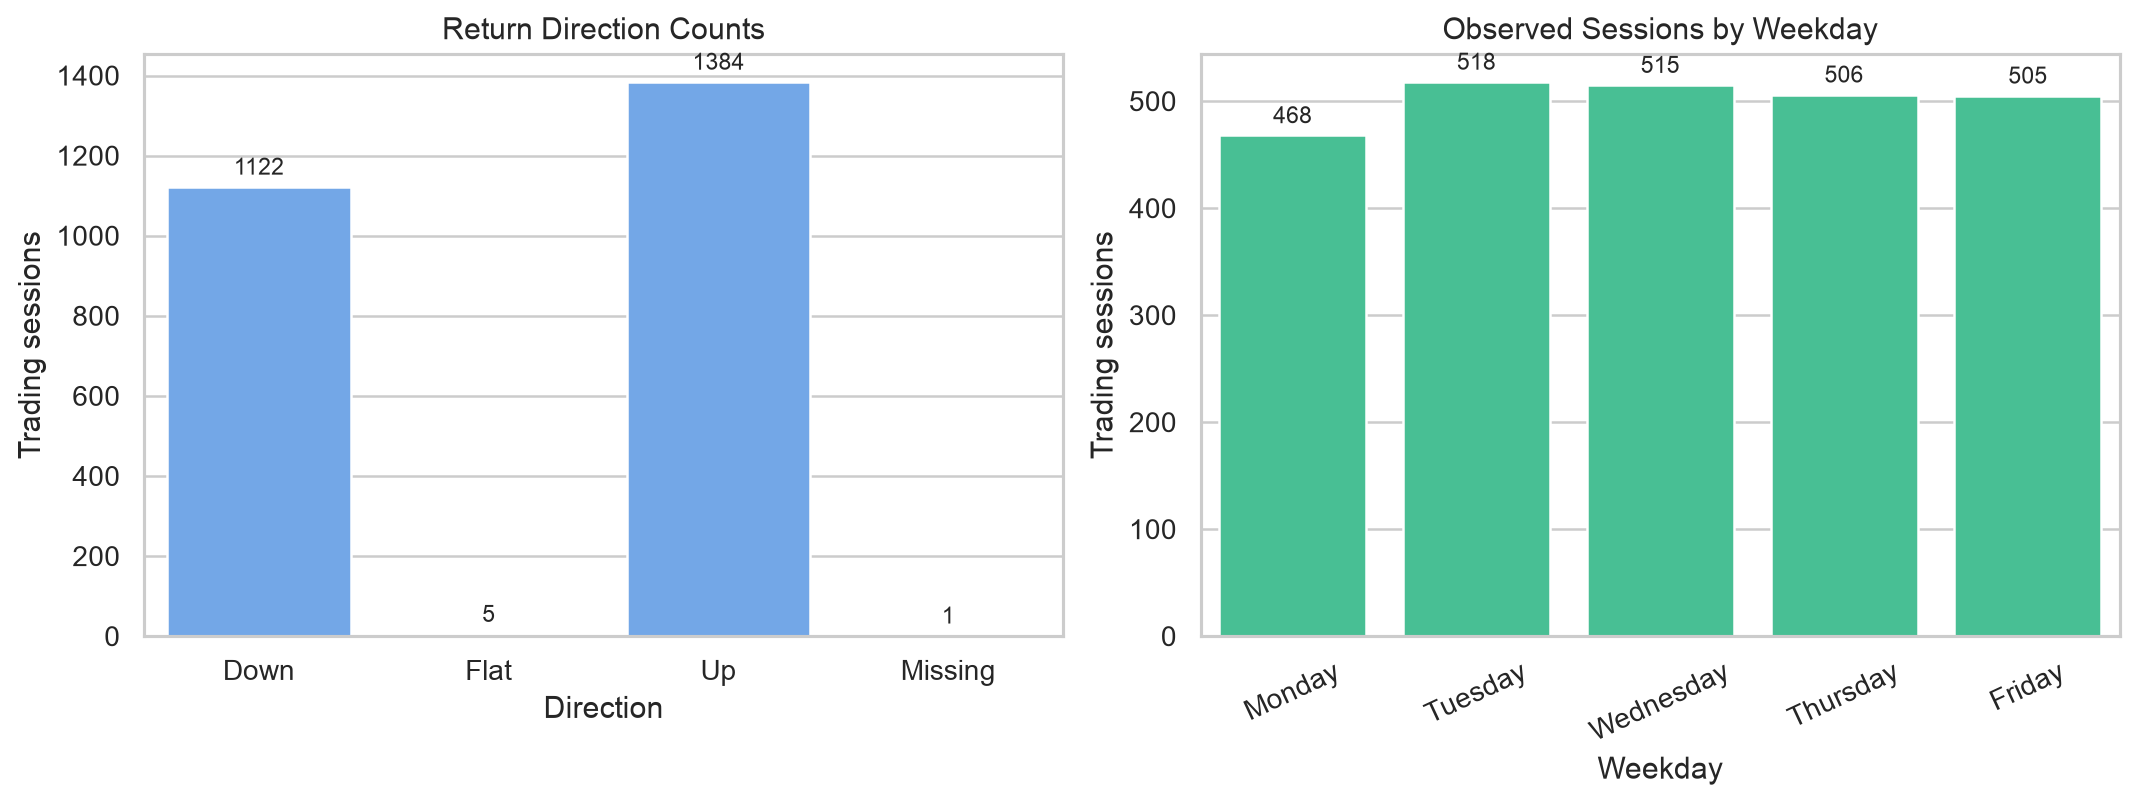

In [8]:
display(summaries["categorical_summary"])
categorical_plot_path = REPORTS / "categorical_profiles.png"
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
sns.countplot(data=eda_df, x="return_direction", color="#60A5FA", ax=axes[0])
axes[0].set_title("Return Direction Counts")
axes[0].set_xlabel("Direction")
axes[0].set_ylabel("Trading sessions")
axes[0].bar_label(axes[0].containers[0], padding=3, fontsize=9)
sns.countplot(data=eda_df, x="weekday_name", color="#34D399", ax=axes[1])
axes[1].set_title("Observed Sessions by Weekday")
axes[1].set_xlabel("Weekday")
axes[1].set_ylabel("Trading sessions")
axes[1].bar_label(axes[1].containers[0], padding=3, fontsize=9)
axes[1].tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(categorical_plot_path, dpi=180, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(categorical_plot_path)))

## 6. Distributional profiles

The four panels exceed the three-distribution requirement. Returns have a narrow center with large tails; absolute returns, intraday range, and volume are strongly right-skewed. This motivates robust transforms and explicit tail diagnostics rather than normality assumptions.

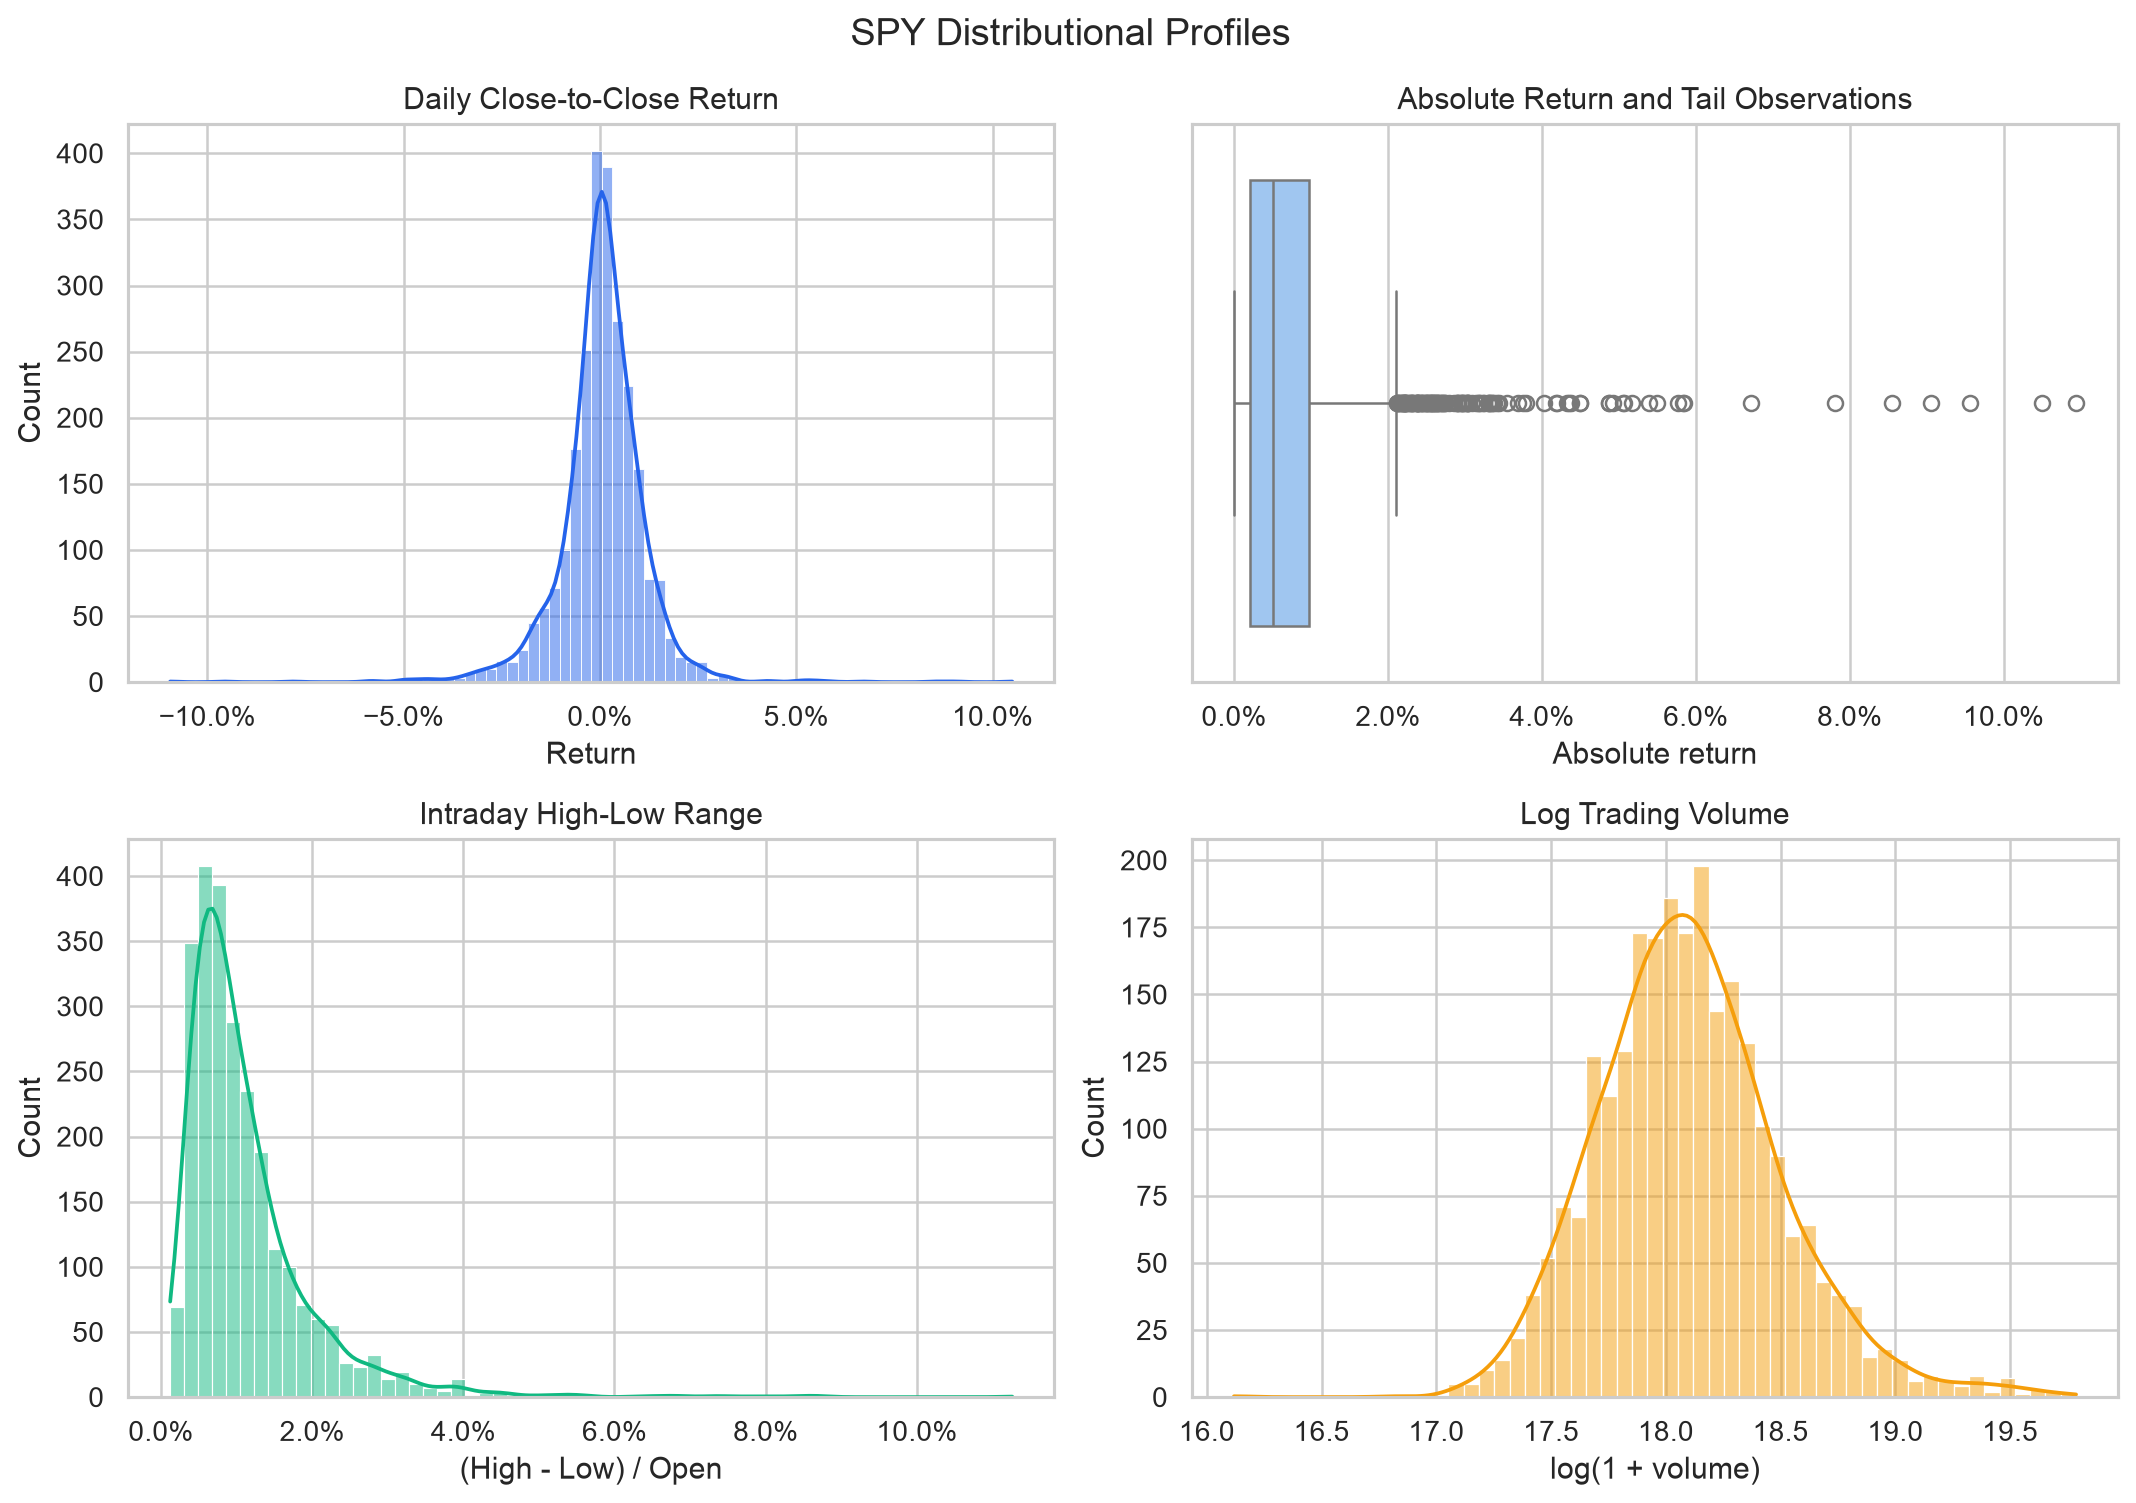

In [9]:
distribution_path = REPORTS / "distributions.png"
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))
sns.histplot(eda_df["daily_return"].dropna(), bins=80, kde=True, color="#2563EB", ax=axes[0, 0])
axes[0, 0].set_title("Daily Close-to-Close Return")
axes[0, 0].set_xlabel("Return")
axes[0, 0].xaxis.set_major_formatter(PercentFormatter(1.0))
sns.boxplot(x=eda_df["abs_return"], color="#93C5FD", ax=axes[0, 1])
axes[0, 1].set_title("Absolute Return and Tail Observations")
axes[0, 1].set_xlabel("Absolute return")
axes[0, 1].xaxis.set_major_formatter(PercentFormatter(1.0))
sns.histplot(eda_df["intraday_range"], bins=60, kde=True, color="#10B981", ax=axes[1, 0])
axes[1, 0].set_title("Intraday High-Low Range")
axes[1, 0].set_xlabel("(High - Low) / Open")
axes[1, 0].xaxis.set_major_formatter(PercentFormatter(1.0))
sns.histplot(eda_df["log_volume"], bins=55, kde=True, color="#F59E0B", ax=axes[1, 1])
axes[1, 1].set_title("Log Trading Volume")
axes[1, 1].set_xlabel("log(1 + volume)")
fig.suptitle("SPY Distributional Profiles", fontsize=15)
fig.tight_layout()
fig.savefig(distribution_path, dpi=180, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(distribution_path)))

## 7. Bivariate relationships

Absolute return rises with both intraday range and log volume, especially during tail sessions. These are contemporaneous associations: Stage 09 must lag them before claiming they can help predict the next session.

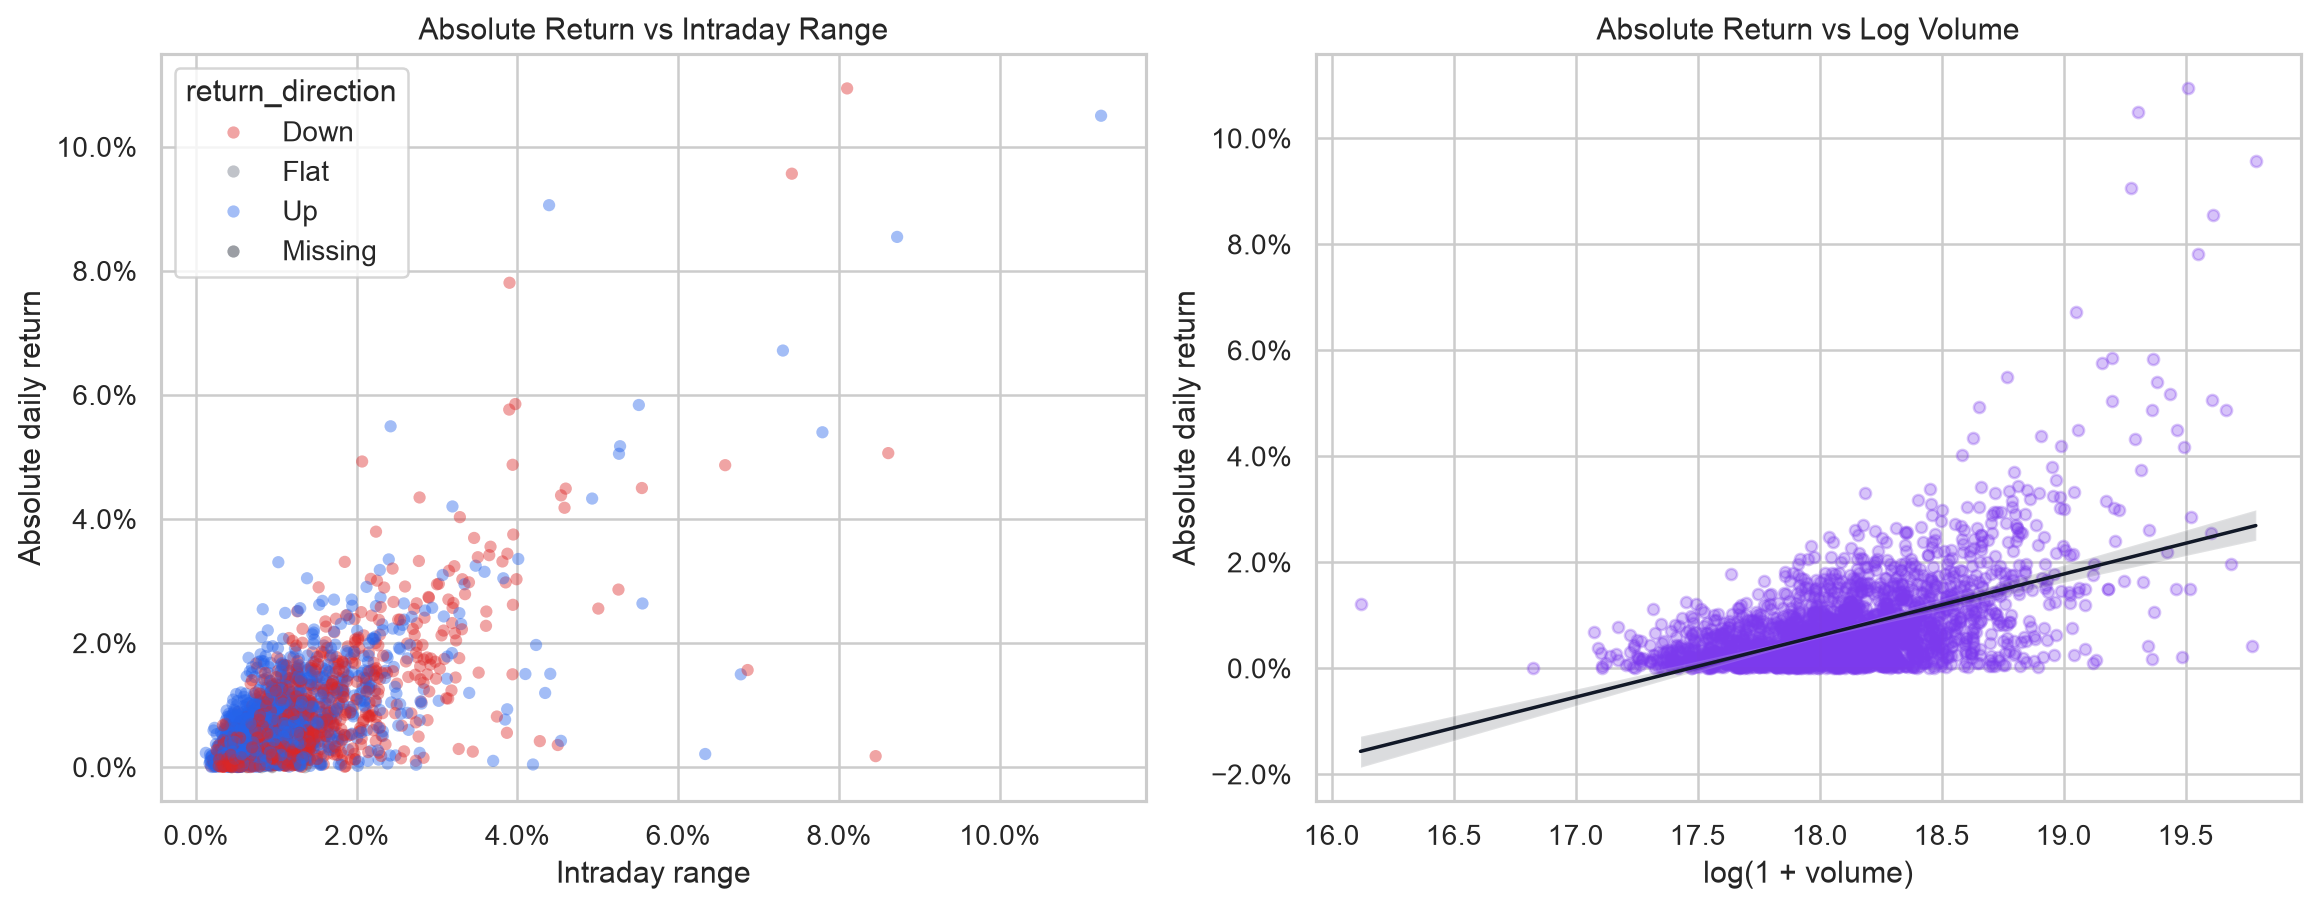

In [10]:
relationship_path = REPORTS / "relationships.png"
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
relationship_data = eda_df.dropna(subset=["abs_return", "intraday_range", "log_volume"])
sns.scatterplot(
    data=relationship_data, x="intraday_range", y="abs_return",
    hue="return_direction", palette={"Down": "#DC2626", "Flat": "#6B7280", "Up": "#2563EB", "Missing": "#111827"},
    alpha=0.42, s=24, linewidth=0, ax=axes[0]
)
axes[0].set_title("Absolute Return vs Intraday Range")
axes[0].set_xlabel("Intraday range")
axes[0].set_ylabel("Absolute daily return")
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
sns.regplot(
    data=relationship_data, x="log_volume", y="abs_return",
    scatter_kws={"alpha": 0.30, "s": 20, "color": "#7C3AED"},
    line_kws={"color": "#111827", "linewidth": 1.4}, ax=axes[1]
)
axes[1].set_title("Absolute Return vs Log Volume")
axes[1].set_xlabel("log(1 + volume)")
axes[1].set_ylabel("Absolute daily return")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
fig.tight_layout()
fig.savefig(relationship_path, dpi=180, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(relationship_path)))

## 8. Time-series structure

The unadjusted closing-price level trends upward and is not stationary. Rolling volatility is clustered rather than constant, with a dominant March 2020 regime and additional elevated periods in 2022 and 2025. No stable seasonal cycle is obvious from this plot. Stage 09 should emphasize returns, lags, and rolling risk measures; Stage 10b must use chronological rather than random splits and report performance across regimes.

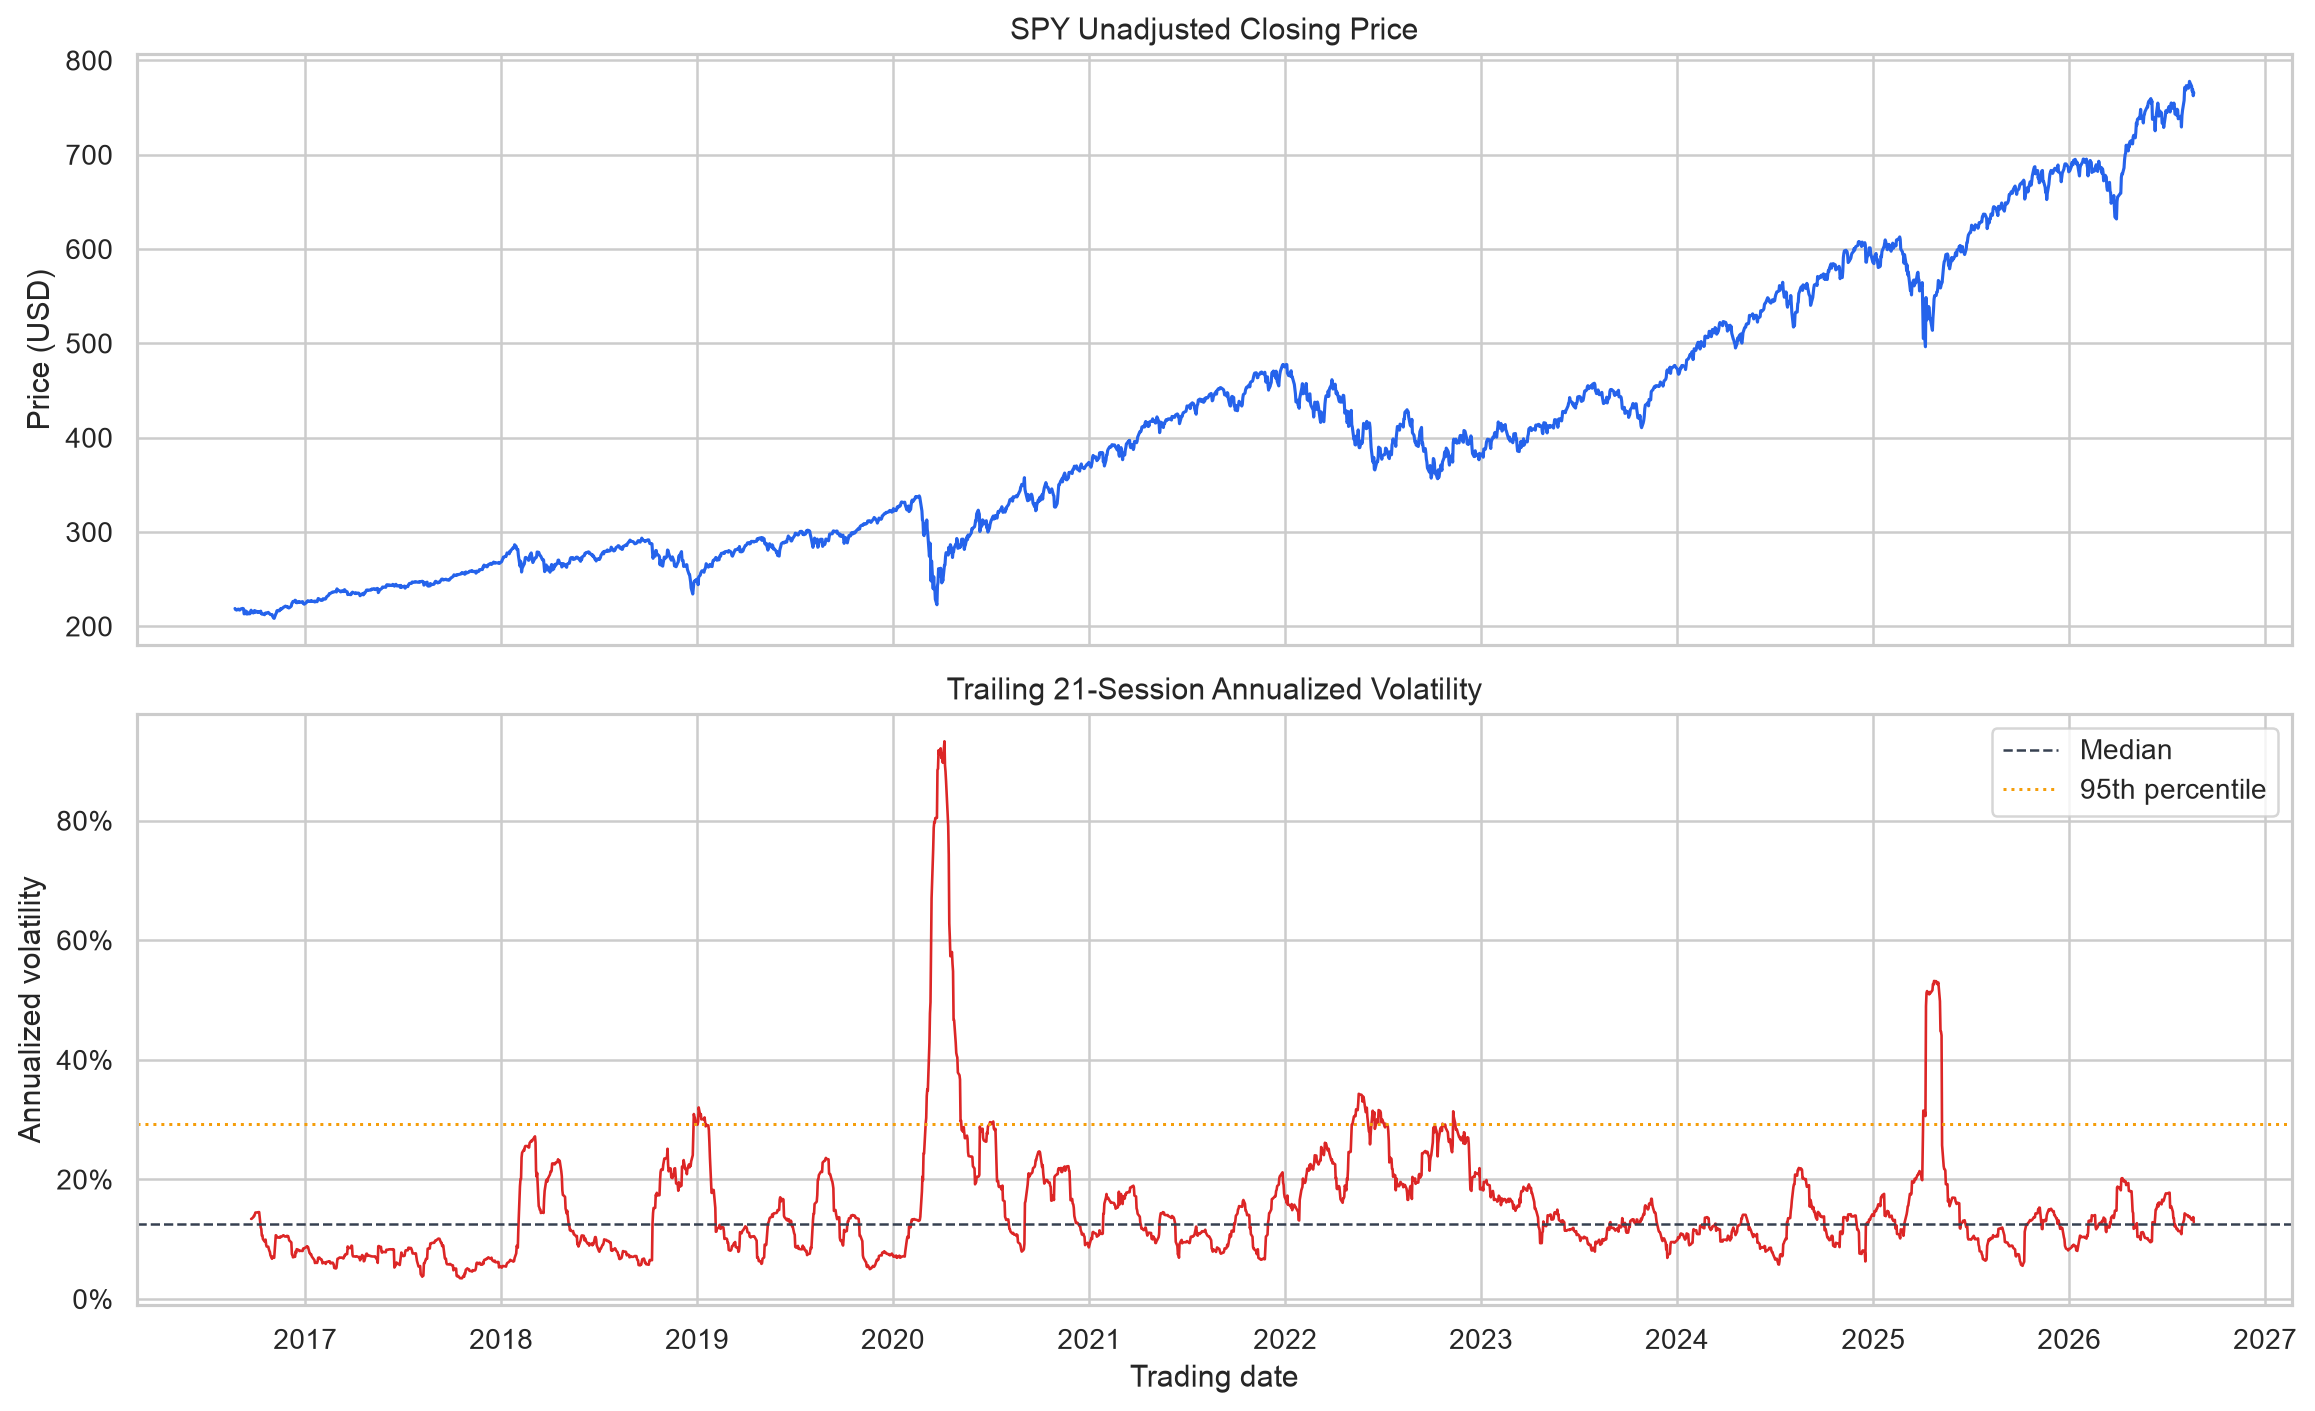

In [11]:
time_series_path = REPORTS / "time_series.png"
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(eda_df["date"], eda_df["close"], color="#2563EB", linewidth=1.25)
axes[0].set_title("SPY Unadjusted Closing Price")
axes[0].set_ylabel("Price (USD)")
axes[1].plot(eda_df["date"], eda_df["rolling_vol_21"], color="#DC2626", linewidth=1.05)
vol_median = eda_df["rolling_vol_21"].median()
vol_p95 = eda_df["rolling_vol_21"].quantile(0.95)
axes[1].axhline(vol_median, color="#374151", linestyle="--", linewidth=1, label="Median")
axes[1].axhline(vol_p95, color="#F59E0B", linestyle=":", linewidth=1.2, label="95th percentile")
axes[1].set_title("Trailing 21-Session Annualized Volatility")
axes[1].set_xlabel("Trading date")
axes[1].set_ylabel("Annualized volatility")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend(loc="upper right")
fig.tight_layout()
fig.savefig(time_series_path, dpi=180, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(time_series_path)))

## 9. Correlation heatmap (stretch)

Absolute return correlates strongly with intraday range and moderately with log volume and rolling volatility. Correlation does not establish forecasting value, and the related risk measures may be redundant when entered together.

,daily_return,abs_return,intraday_range,close_to_open_return,log_volume,rolling_vol_21
daily_return,1.000,-0.056,-0.111,0.767,-0.178,0.025
abs_return,-0.056,1.000,0.719,-0.001,0.539,0.530
intraday_range,-0.111,0.719,1.000,-0.029,0.685,0.645
close_to_open_return,0.767,-0.001,-0.029,1.000,-0.118,0.051
log_volume,-0.178,0.539,0.685,-0.118,1.000,0.411
rolling_vol_21,0.025,0.530,0.645,0.051,0.411,1.000


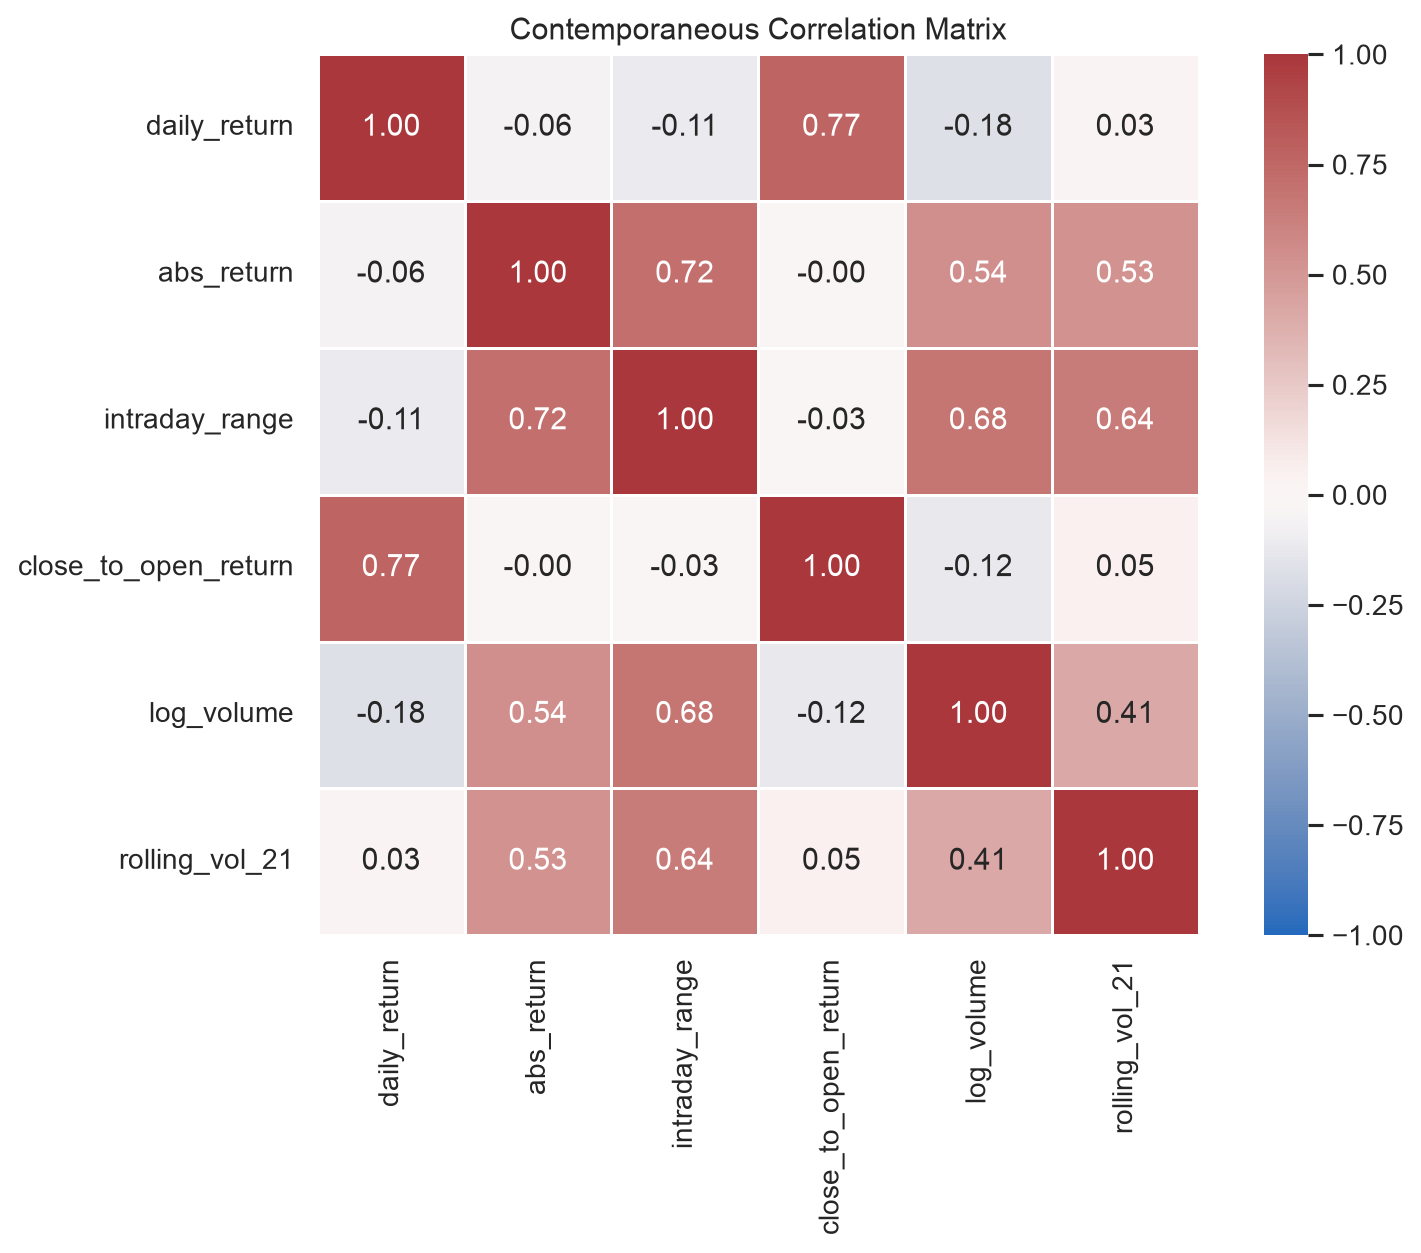

In [12]:
correlation_columns = [
    "daily_return", "abs_return", "intraday_range",
    "close_to_open_return", "log_volume", "rolling_vol_21"
]
correlation_matrix = eda_df[correlation_columns].corr()
correlation_path = PROCESSED / "eda_correlation_matrix.csv"
correlation_matrix.to_csv(correlation_path)
heatmap_path = REPORTS / "correlation_heatmap.png"
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    correlation_matrix, annot=True, fmt=".2f", cmap="vlag",
    vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax
)
ax.set_title("Contemporaneous Correlation Matrix")
fig.tight_layout()
fig.savefig(heatmap_path, dpi=180, bbox_inches="tight")
plt.close(fig)
display(correlation_matrix.round(3))
display(Image(filename=str(heatmap_path)))

## 10. Daily versus monthly granularity (stretch)

Daily data reveal individual tail sessions and short volatility bursts. Monthly aggregation makes regimes and longer drawdown/recovery periods easier to compare but hides within-month path and extremes. Both views are useful; neither should replace the daily sequence required for the next-session target.

In [13]:
monthly_profile = (
    eda_df.set_index("date")
    .resample("ME")
    .agg(
        sessions=("close", "size"),
        ending_close=("close", "last"),
        monthly_return=("daily_return", lambda values: (1 + values.dropna()).prod() - 1),
        realized_vol_annualized=("daily_return", lambda values: values.std(ddof=1) * np.sqrt(252)),
        average_volume=("volume", "mean"),
        average_intraday_range=("intraday_range", "mean"),
    )
    .reset_index()
)
monthly_path = PROCESSED / "eda_monthly_profile.csv"
monthly_profile.to_csv(monthly_path, index=False, date_format="%Y-%m-%d")
print("Highest-volatility months")
display(
    monthly_profile.nlargest(10, "realized_vol_annualized")[
        ["date", "sessions", "monthly_return", "realized_vol_annualized"]
    ]
)
print("Daily return vs monthly return summary")
display(
    pd.DataFrame(
        {
            "daily_return": eda_df["daily_return"].describe(),
            "monthly_return": monthly_profile["monthly_return"].describe(),
        }
    )
)

Highest-volatility months


,date,sessions,monthly_return,realized_vol_annualized
43,2020-03-31,22,-0.129987,0.899623
104,2025-04-30,21,-0.008670,0.526936
44,2020-04-30,21,0.126984,0.404035
69,2022-05-31,21,0.002257,0.312678
28,2018-12-31,19,-0.093343,0.304359
70,2022-06-30,21,-0.086407,0.296179
46,2020-06-30,22,0.013275,0.289027
75,2022-11-30,21,0.055592,0.279098
74,2022-10-31,21,0.081276,0.278928
18,2018-02-28,19,-0.036360,0.277307


Daily return vs monthly return summary


,daily_return,monthly_return
count,2511.000000,121.000000
mean,0.000563,0.011387
std,0.011360,0.044518
min,-0.109424,-0.129987
25%,-0.003705,-0.008924
50%,0.000696,0.015926
75%,0.005983,0.036198
max,0.105019,0.126984


## 11. Top 3 insights

1. **Heavy tails are central, not incidental.** Daily returns have excess kurtosis around 14.7; absolute return, intraday range, volume, and rolling volatility are strongly right-skewed. Extreme sessions should be retained and modeled rather than deleted mechanically.
2. **Range and activity are useful risk context.** Absolute return correlates approximately 0.72 with intraday range and 0.54 with log volume. Stage 09 should test their lagged and rolling versions, then check redundancy and stability by regime.
3. **Risk clusters through time.** March 2020 is the strongest volatility regime, with additional elevated periods in 2022 and 2025. Chronological splits and regime-specific evaluation are necessary; a random split would distribute crisis observations across training and testing.

### Assumptions and risks

Nasdaq prices are unadjusted, so distribution dates may affect measured returns. The first return and first 21 rolling-volatility values are structurally missing. Generic weekday gaps largely represent exchange holidays, and row-based rolling windows therefore mean trading sessions rather than calendar days. Contemporaneous correlations do not prove causality or next-session predictiveness.

### Implications for next step

Stage 09 should create lagged returns, absolute returns, intraday range, log-volume changes, and rolling volatility using information available no later than the current close. The next-session high-volatility target must be shifted explicitly, and its percentile threshold must be fitted on training data only. Use returns/ratios rather than raw price levels, preserve tail sessions, and prepare chronological train/validation/test splits.

In [14]:
processed_outputs = [
    column_profile_path, numeric_summary_path, categorical_summary_path,
    correlation_path, monthly_path
]
plot_outputs = [
    categorical_plot_path, distribution_path, relationship_path,
    time_series_path, heatmap_path
]
assert df.shape == (2512, 6)
assert not df.isna().any().any()
assert df["date"].is_unique and df["date"].is_monotonic_increasing
assert int(eda_df["daily_return"].isna().sum()) == 1
assert int(eda_df["rolling_vol_21"].isna().sum()) == 21
assert set(summaries["categorical_summary"]["column"]) == {
    "return_direction", "weekday_name"
}
assert correlation_matrix.loc["abs_return", "intraday_range"] > 0.65
assert len(monthly_profile) >= 120
assert all(path.exists() and path.stat().st_size > 0 for path in processed_outputs)
assert all(path.exists() and path.stat().st_size > 0 for path in plot_outputs)
print("Stage 08 profiling, visualization, time-series, and artifact checks passed.")

Stage 08 profiling, visualization, time-series, and artifact checks passed.
